# End-to-End ML Pipeline on Tesla Deliveries & Price Dataset

This notebook demonstrates:
1. Data Loading
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Regression Modeling
6. Hyperparameter Tuning
7. Time Series Forecasting
8. Model Evaluation

Suitable for resume statement:

**Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.**


In [6]:
!pip install matplotlib seaborn pandas numpy scikit-learn statsmodels

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import warnings
warnings.filterwarnings('ignore')


In [13]:
# Load Dataset
df = pd.read_csv(
    'tesla_deliveries_dataset_2015_2025.csv',
    encoding='ISO-8859-1',
    on_bad_lines='skip'
)

print(df.head())
print(df.columns)


   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [14]:
# Basic Information
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Exploratory Data Analysis (EDA)

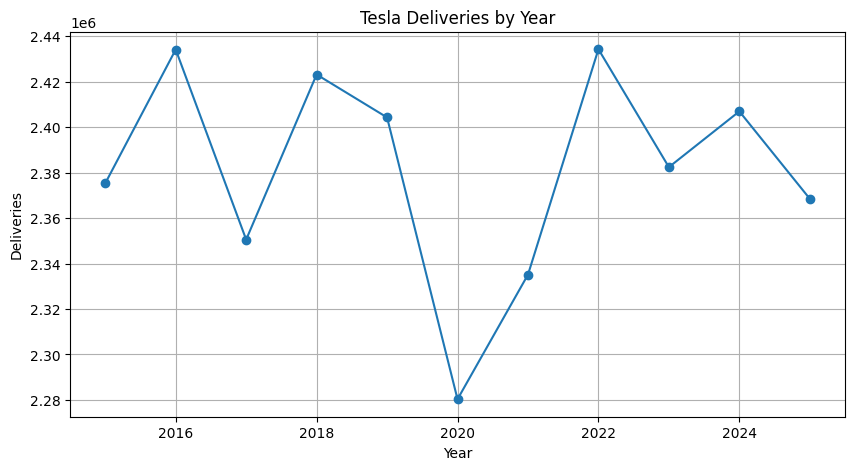

In [15]:
# Deliveries by Year
yearly_sales = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot(marker='o')
plt.title('Tesla Deliveries by Year')
plt.ylabel('Deliveries')
plt.grid(True)
plt.show()


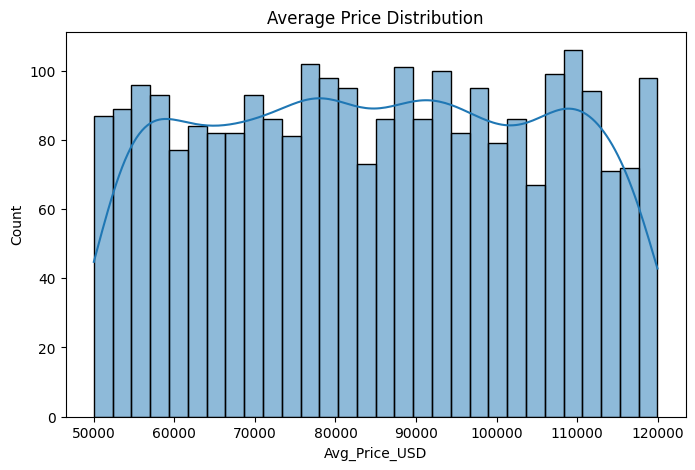

In [16]:
# Average Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Price_USD'], bins=30, kde=True)
plt.title('Average Price Distribution')
plt.show()


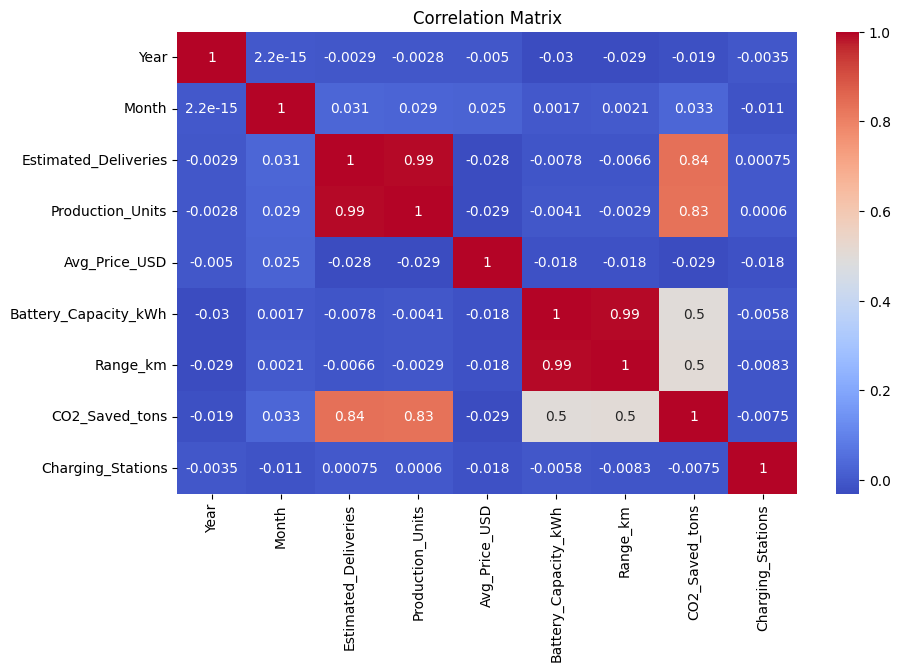

In [17]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


## Feature Engineering

In [18]:
# Create date feature
df['Date'] = pd.to_datetime(
    dict(year=df['Year'], month=df['Month'], day=1)
)

# Production efficiency
df['Production_Efficiency'] = (
    df['Estimated_Deliveries'] / df['Production_Units']
)

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Production_Efficiency
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,0.984600
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,0.911864
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,0.915334
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,0.896594
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,0.914087


## Regression Problem: Predict Average Price

In [19]:
target = 'Avg_Price_USD'

X = df.drop(columns=[target, 'Date'])
y = df[target]

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
# Baseline Random Forest Model

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

print("MAE:", round(mae := mean_absolute_error(y_test, preds),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, preds)),2))
print("R2 Score:", round(r2_score(y_test, preds),4))


MAE: 17164.89
RMSE: 20064.94
R2 Score: -0.0676


## Hyperparameter Tuning

In [21]:
param_grid = {
    'model__n_estimators':[100,200],
    'model__max_depth':[10,20,None],
    'model__min_samples_split':[2,5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

preds = best_model.predict(X_test)

print("\nTuned Model Results")
print("MAE:", round(mean_absolute_error(y_test,preds),2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test,preds)),2))
print("R2:", round(r2_score(y_test,preds),4))


Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Tuned Model Results
MAE: 16968.61
RMSE: 19797.93
R2: -0.0394


## Time Series Forecasting of Deliveries

In [22]:
monthly_sales = (
    df.groupby('Date')['Estimated_Deliveries']
    .sum()
    .sort_index()
)

monthly_sales.head()


Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64

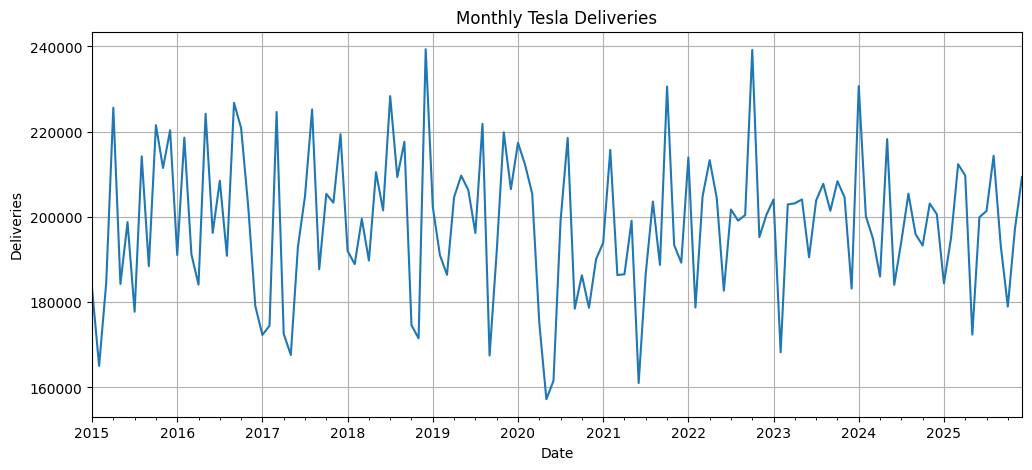

In [23]:
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title('Monthly Tesla Deliveries')
plt.ylabel('Deliveries')
plt.grid(True)
plt.show()


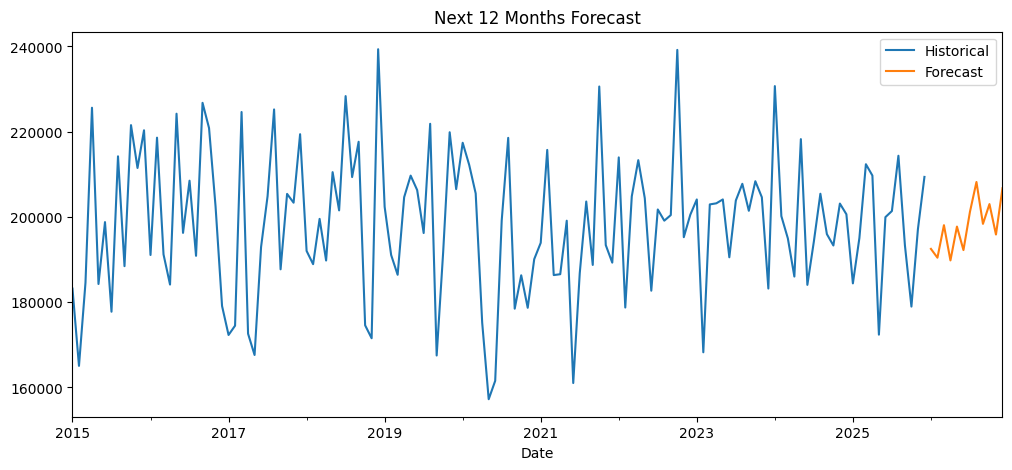

2026-01-01    192502.675181
2026-02-01    190434.243491
2026-03-01    198069.624184
2026-04-01    189793.326414
2026-05-01    197736.046555
2026-06-01    192219.127283
2026-07-01    201205.047031
2026-08-01    208205.137998
2026-09-01    198373.656804
2026-10-01    203016.019901
2026-11-01    195869.546753
2026-12-01    206737.958354
Freq: MS, dtype: float64

In [24]:
# Exponential Smoothing Forecast

model = ExponentialSmoothing(
    monthly_sales,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

fit = model.fit()

forecast = fit.forecast(12)

plt.figure(figsize=(12,5))
monthly_sales.plot(label='Historical')
forecast.plot(label='Forecast')
plt.legend()
plt.title('Next 12 Months Forecast')
plt.show()

forecast


## Project Conclusion

- Performed data cleaning and preprocessing.
- Conducted exploratory data analysis (EDA).
- Created engineered features such as production efficiency and date variables.
- Built a machine learning regression model to predict vehicle prices.
- Applied hyperparameter tuning using GridSearchCV.
- Implemented time series forecasting for future Tesla deliveries.
- Evaluated model performance using MAE, RMSE, and R².
